# Questão 02: Implementação do Algoritmo Backpropagation Manual

Este notebook implementa o algoritmo Backpropagation do zero para uma Rede Neural MLP (Multi-Layer Perceptron) com uma camada oculta. O objetivo é resolver as funções lógicas AND, OR e XOR com n entradas booleanas e investigar a importância da taxa de aprendizado, do bias e de diferentes funções de ativação.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import time

# Para plotagem interativa no Jupyter Notebook / VS Code, 
# %matplotlib notebook ou %matplotlib ipympl podem ser úteis.
# Descomente uma se necessário e instale o pacote (ex: pip install ipympl)
# %matplotlib notebook 
# %matplotlib ipympl

## Funções Auxiliares

In [2]:
def gerar_dados(n_entradas, tipo_funcao='AND'):
    """
    Gera dados para funções lógicas AND, OR, XOR com n_entradas.
    (Reutilizada da Questão 01)
    """
    X = np.array(list(product([0, 1], repeat=n_entradas)))
    if tipo_funcao.upper() == 'AND':
        y = np.array([int(np.all(x_i)) for x_i in X])
    elif tipo_funcao.upper() == 'OR':
        y = np.array([int(np.any(x_i)) for x_i in X])
    elif tipo_funcao.upper() == 'XOR':
        if n_entradas != 2 and tipo_funcao.upper() == 'XOR': # Mensagem mais específica para XOR
             print(f"Atenção: XOR para n={n_entradas} (n!=2) é definido como paridade (soma das entradas % 2 == 1).")
        y = np.array([np.sum(x_i) % 2 for x_i in X]) 
    else:
        raise ValueError("Função lógica inválida. Use 'AND', 'OR' ou 'XOR'.")
    return X, y.reshape(-1, 1) # Garante que y seja um vetor coluna (N_amostras, 1)

def plotar_curva_erro(erros_por_epoca, titulo_plot, ax=None):
    """
    Plota a curva de erro (custo) por época.
    Pode receber um eixo (ax) para plotar ou criar uma nova figura.
    """
    if ax is None:
        fig_erro, ax = plt.subplots(figsize=(8,5)) # Aumentei um pouco o tamanho
    
    ax.plot(range(1, len(erros_por_epoca) + 1), erros_por_epoca, marker='.', linestyle='-', color='darkcyan') # Estilo alterado
    ax.set_xlabel('Época', fontsize=12)
    ax.set_ylabel('Erro Médio (Custo)', fontsize=12) # Ajustado para "Erro Médio (Custo)"
    ax.set_title(titulo_plot, fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    if not hasattr(ax.figure, 'canvas') or ax.figure.canvas is None: # Se não estiver em um contexto de figura com canvas
        plt.show()
    else: # Se estiver plotando em um eixo existente de uma figura com canvas (ex: subplots)
        ax.figure.canvas.draw_idle()


# (Opcional, para depois) Função para plotar fronteira de decisão 2D
# def plotar_fronteira_decisao_2d(X, y, model, ax, titulo_plot):
#     # ... implementação futura ...
#     pass

## Classe da Rede Neural MLP com Backpropagation

In [3]:
class RedeNeuralMLP:
    def __init__(self, n_entradas, n_oculta, n_saida=1, 
                 func_ativacao_oculta='sigmoide', 
                 func_ativacao_saida='sigmoide', 
                 usar_bias=True):
        """
        Inicializa a Rede Neural MLP.
        Args:
            n_entradas (int): Número de neurônios na camada de entrada (igual ao número de características).
            n_oculta (int): Número de neurônios na camada oculta.
            n_saida (int): Número de neurônios na camada de saída (geralmente 1 para classificação binária).
            func_ativacao_oculta (str): 'sigmoide', 'tanh', ou 'relu' para a camada oculta.
            func_ativacao_saida (str): 'sigmoide', 'tanh', ou 'linear' para a camada de saída.
                                       (Para classificação binária com entropia cruzada, sigmoide é comum).
            usar_bias (bool): Se True, inclui neurônios de bias.
        """
        self.n_entradas = n_entradas
        self.n_oculta = n_oculta
        self.n_saida = n_saida
        self.usar_bias = usar_bias

        # Inicialização dos pesos e biases
        # Pesos W1: (n_entradas + bias_node) x n_oculta
        # Pesos W2: (n_oculta + bias_node) x n_saida
        input_dim_W1 = self.n_entradas + 1 if self.usar_bias else self.n_entradas
        input_dim_W2 = self.n_oculta + 1 if self.usar_bias else self.n_oculta

        # Xavier/Glorot initialization (ou He para ReLU) pode ser melhor, mas vamos começar simples
        self.W1 = np.random.randn(input_dim_W1, self.n_oculta) * 0.1 
        self.W2 = np.random.randn(input_dim_W2, self.n_saida) * 0.1
        
        # Se não usar bias, os biases podem ser considerados zero ou não existir.
        # No nosso caso, a dimensão dos pesos já considera o bias se self.usar_bias for True.
        # Se self.usar_bias for False, a entrada não terá o '1' adicionado.

        # Seleção das funções de ativação e suas derivadas
        self._set_funcao_ativacao('oculta', func_ativacao_oculta)
        self._set_funcao_ativacao('saida', func_ativacao_saida)

        # Histórico de erros para plotagem
        self.historico_custo = []

    def _set_funcao_ativacao(self, camada_tipo, nome_funcao):
        if nome_funcao == 'sigmoide':
            ativacao = self._sigmoide
            derivada = self._sigmoide_derivada
        elif nome_funcao == 'tanh':
            ativacao = self._tanh
            derivada = self._tanh_derivada
        elif nome_funcao == 'relu':
            ativacao = self._relu
            derivada = self._relu_derivada
        elif nome_funcao == 'linear':
            ativacao = self._linear
            derivada = self._linear_derivada
        else:
            raise ValueError(f"Função de ativação '{nome_funcao}' não suportada.")

        if camada_tipo == 'oculta':
            self.ativacao_oculta = ativacao
            self.derivada_ativacao_oculta = derivada
        elif camada_tipo == 'saida':
            self.ativacao_saida = ativacao
            self.derivada_ativacao_saida = derivada

    # --- Funções de Ativação e Derivadas ---
    def _sigmoide(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500))) # Clip para evitar overflow
    def _sigmoide_derivada(self, x_ativado): # Recebe a saída da sigmoide
        return x_ativado * (1 - x_ativado)

    def _tanh(self, x):
        return np.tanh(x)
    def _tanh_derivada(self, x_ativado): # Recebe a saída da tanh
        return 1 - x_ativado**2

    def _relu(self, x):
        return np.maximum(0, x)
    def _relu_derivada(self, x_ativado): # Recebe a saída da relu (ou a entrada Z para ela)
                                         # Se receber x_ativado (saída da relu), então x_ativado > 0 implica gradiente 1.
        deriv = np.zeros_like(x_ativado)
        deriv[x_ativado > 0] = 1
        return deriv
        # Alternativamente, se passarmos Z (entrada da relu):
        # deriv = np.zeros_like(Z)
        # deriv[Z > 0] = 1
        # return deriv

    def _linear(self, x):
        return x
    def _linear_derivada(self, x_ativado): # Ou Z
        return np.ones_like(x_ativado)

    def _adicionar_bias_a_entrada(self, X_camada):
        """Adiciona uma coluna de 1s para o bias na matriz de entrada da camada."""
        if self.usar_bias:
            return np.insert(X_camada, 0, 1, axis=1)
        return X_camada

    def feedforward(self, X_entrada_batch):
        """
        Calcula a propagação direta (feedforward).
        Retorna as saídas de cada camada (A0, Z1, A1, Z2, A2).
        A0 é a entrada da rede (X_entrada_batch com bias se aplicável).
        """
        # Camada de Entrada para Oculta
        self.A0 = self._adicionar_bias_a_entrada(X_entrada_batch) if self.usar_bias else X_entrada_batch
        
        # Ajuste das dimensões de W1 se o bias não for adicionado em A0 diretamente
        # Se não usamos bias, A0 = X_entrada_batch (sem coluna de 1s)
        # e W1 deveria ser (n_entradas x n_oculta)
        # Se usamos bias, A0 = X_entrada_batch com coluna de 1s
        # e W1 é (n_entradas+1 x n_oculta)
        # Nossa inicialização de W1 já considera self.usar_bias na sua dimensão,
        # então A0 deve ser compatível.

        self.Z1 = np.dot(self.A0, self.W1)
        self.A1_sem_bias = self.ativacao_oculta(self.Z1) # Saída da camada oculta (antes de adicionar bias para a próxima)
        
        # Camada Oculta para Saída
        self.A1_com_bias_para_saida = self._adicionar_bias_a_entrada(self.A1_sem_bias) if self.usar_bias else self.A1_sem_bias
        
        self.Z2 = np.dot(self.A1_com_bias_para_saida, self.W2)
        self.A2_saida_final = self.ativacao_saida(self.Z2) # Saída final da rede (y_hat)
        
        return self.A2_saida_final

    def _calcular_custo(self, y_predito, y_real):
        """Calcula o custo (erro). Entropia Cruzada para classificação binária."""
        m = y_real.shape[0] # Número de amostras
        # Evitar log(0) e log(1) adicionando um pequeno epsilon
        epsilon = 1e-12
        y_predito_clipped = np.clip(y_predito, epsilon, 1 - epsilon)
        
        custo = -1/m * np.sum(y_real * np.log(y_predito_clipped) + (1 - y_real) * np.log(1 - y_predito_clipped))
        return custo

    def backward(self, X_entrada_batch, y_real, y_predito, taxa_aprendizado):
        """
        Realiza o backpropagation e atualiza os pesos e biases.
        Assume que feedforward já foi chamado e self.A0, self.Z1, self.A1_sem_bias, 
        self.A1_com_bias_para_saida, self.Z2, self.A2_saida_final estão preenchidos.
        """
        m = X_entrada_batch.shape[0] # Número de amostras no batch

        # 1. Erro na camada de saída
        # Para entropia cruzada com sigmoide na saída, delta2 é simplesmente (y_predito - y_real)
        # Se a função de ativação da saída for linear e o custo for MSE, então
        # delta2 = (y_predito - y_real) * self.derivada_ativacao_saida(self.Z2) # ou self.A2_saida_final
        # Vamos usar a forma simplificada para sigmoide/entropia cruzada.
        # Se outra func de ativação/custo for usada na saída, esta parte precisa ser mais genérica.
        if self.ativacao_saida == self._sigmoide: # Assumindo custo de Entropia Cruzada
            delta2 = (y_predito - y_real)
        else: # Forma mais geral
             delta2 = (y_predito - y_real) * self.derivada_ativacao_saida(self.A2_saida_final)


        # 2. Gradientes para W2 e b2 (b2 está incluído em W2 se usarmos bias)
        # dW2 precisa de A1 (com bias se usado)
        dW2 = (1/m) * np.dot(self.A1_com_bias_para_saida.T, delta2)

        # 3. Erro na camada oculta
        # delta1 precisa de W2 (sem a parte do bias de W2, se self.usar_bias)
        W2_sem_bias_para_erro_oculto = self.W2[1:, :] if self.usar_bias else self.W2 # Remove a linha do bias de W2
        
        delta1 = np.dot(delta2, W2_sem_bias_para_erro_oculto.T) * self.derivada_ativacao_oculta(self.A1_sem_bias)

        # 4. Gradientes para W1 e b1 (b1 está incluído em W1 se usarmos bias)
        # dW1 precisa de A0 (entrada original X_entrada_batch com bias se usado)
        dW1 = (1/m) * np.dot(self.A0.T, delta1)
        
        # 5. Atualização dos pesos
        self.W2 -= taxa_aprendizado * dW2
        self.W1 -= taxa_aprendizado * dW1
        
        # Se não usamos bias, W1 e W2 já têm as dimensões corretas.
        # Se usamos bias, a primeira linha/coluna de W1/W2 corresponde aos biases.

    def train(self, X_treino, y_treino, taxa_aprendizado, n_epocas_treino):
        self.historico_custo = [] # Limpa histórico para novo treino

        for epoca in range(n_epocas_treino):
            # Feedforward
            y_predito_treino = self.feedforward(X_treino)
            
            # Calcular custo
            custo_epoca = self._calcular_custo(y_predito_treino, y_treino)
            self.historico_custo.append(custo_epoca)
            
            # Backward (Retropropagação e atualização dos pesos)
            self.backward(X_treino, y_treino, y_predito_treino, taxa_aprendizado)
            
            if (epoca + 1) % (n_epocas_treino // 10 if n_epocas_treino >= 10 else 1) == 0: # Imprime progresso
                print(f"Época {epoca+1}/{n_epocas_treino}, Custo: {custo_epoca:.6f}")
        
        print(f"Treinamento concluído. Custo final: {self.historico_custo[-1]:.6f}")

    def predict_proba(self, X_teste):
        """Retorna as probabilidades da saída (após feedforward)."""
        return self.feedforward(X_teste)

    def predict_classes(self, X_teste, limiar=0.5):
        """Retorna as classes preditas (0 ou 1) com base no limiar."""
        probabilidades = self.predict_proba(X_teste)
        return (probabilidades >= limiar).astype(int)

## Testando a Rede Neural MLP

Vamos realizar alguns testes básicos para verificar a inicialização, o feedforward e o processo de treinamento da nossa classe `RedeNeuralMLP`.

In [4]:
# Teste de Inicialização
print("--- Testando Inicialização da Rede Neural MLP ---")

# Parâmetros de exemplo
n_entradas_ex = 2
n_oculta_ex = 3
n_saida_ex = 1

# Criar uma instância da rede
rede_teste = RedeNeuralMLP(n_entradas=n_entradas_ex, 
                           n_oculta=n_oculta_ex, 
                           n_saida=n_saida_ex,
                           func_ativacao_oculta='sigmoide',
                           func_ativacao_saida='sigmoide',
                           usar_bias=True)

print(f"Rede criada com {n_entradas_ex} entradas, {n_oculta_ex} neurônios ocultos, {n_saida_ex} saída.")
print(f"Usar bias: {rede_teste.usar_bias}")

# Verificar as dimensões dos pesos (considerando o bias)
# W1 deve ser (n_entradas + 1) x n_oculta
# W2 deve ser (n_oculta + 1) x n_saida
expected_W1_shape = (n_entradas_ex + 1, n_oculta_ex) if rede_teste.usar_bias else (n_entradas_ex, n_oculta_ex)
expected_W2_shape = (n_oculta_ex + 1, n_saida_ex) if rede_teste.usar_bias else (n_oculta_ex, n_saida_ex)

print(f"Dimensões de W1: Esperado {expected_W1_shape}, Obtido {rede_teste.W1.shape}")
print(f"Dimensões de W2: Esperado {expected_W2_shape}, Obtido {rede_teste.W2.shape}")

assert rede_teste.W1.shape == expected_W1_shape, "Erro na dimensão de W1!"
assert rede_teste.W2.shape == expected_W2_shape, "Erro na dimensão de W2!"

print(f"Função de ativação da camada oculta: {rede_teste.ativacao_oculta.__name__}")
print(f"Função de ativação da camada de saída: {rede_teste.ativacao_saida.__name__}")

print("\n--- Teste de Inicialização Concluído ---")

--- Testando Inicialização da Rede Neural MLP ---
Rede criada com 2 entradas, 3 neurônios ocultos, 1 saída.
Usar bias: True
Dimensões de W1: Esperado (3, 3), Obtido (3, 3)
Dimensões de W2: Esperado (4, 1), Obtido (4, 1)
Função de ativação da camada oculta: _sigmoide
Função de ativação da camada de saída: _sigmoide

--- Teste de Inicialização Concluído ---


In [5]:
# Teste do Feedforward
print("\n--- Testando Feedforward ---")

# Usar a 'rede_teste' criada na célula anterior
# Dados de entrada de exemplo (ex: para 2 entradas)
X_ex_ff = np.array([[0, 0],
                    [0, 1],
                    [1, 0],
                    [1, 1]])

# Executar o feedforward
saidas_preditas_ff = rede_teste.feedforward(X_ex_ff)

print("Entradas para o feedforward (X_ex_ff):")
print(X_ex_ff)
print("\nSaídas preditas (probabilidades) após o feedforward:")
print(saidas_preditas_ff)

# Verificar a dimensão da saída
# Deve ser (numero_de_amostras, n_saida_ex)
expected_output_shape = (X_ex_ff.shape[0], n_saida_ex)
print(f"\nDimensão da Saída: Esperado {expected_output_shape}, Obtido {saidas_preditas_ff.shape}")
assert saidas_preditas_ff.shape == expected_output_shape, "Erro na dimensão da saída do feedforward!"

# Verificar se os valores estão entre 0 e 1 (para saída sigmoide)
if rede_teste.ativacao_saida == rede_teste._sigmoide:
    assert np.all(saidas_preditas_ff >= 0) and np.all(saidas_preditas_ff <= 1), \
        "Erro: Saídas da sigmoide fora do intervalo [0, 1]!"
    print("Valores da saída (sigmoide) estão no intervalo [0, 1] - OK.")

print("\n--- Teste de Feedforward Concluído ---")

# Verificando as ativações internas (para depuração, se necessário)
# print("\nAtivações internas do último feedforward:")
# print(f"A0 (entrada com bias, se usado):\n{rede_teste.A0}")
# print(f"Z1 (entrada da camada oculta):\n{rede_teste.Z1}")
# print(f"A1_sem_bias (saída da camada oculta antes do bias para a próxima):\n{rede_teste.A1_sem_bias}")
# print(f"A1_com_bias_para_saida (entrada da camada de saída com bias, se usado):\n{rede_teste.A1_com_bias_para_saida}")
# print(f"Z2 (entrada da camada de saída):\n{rede_teste.Z2}")
# print(f"A2_saida_final (saída final da rede):\n{rede_teste.A2_saida_final}")


--- Testando Feedforward ---
Entradas para o feedforward (X_ex_ff):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Saídas preditas (probabilidades) após o feedforward:
[[0.43292291]
 [0.43383374]
 [0.43283049]
 [0.4337556 ]]

Dimensão da Saída: Esperado (4, 1), Obtido (4, 1)
Valores da saída (sigmoide) estão no intervalo [0, 1] - OK.

--- Teste de Feedforward Concluído ---



--- Testando Treinamento Completo (Exemplo: Função AND) ---
Dados de Treinamento (AND):
X_and:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
y_and:
 [[0]
 [0]
 [0]
 [1]]

Iniciando treinamento para AND com taxa=0.1, épocas=5000...
Época 500/5000, Custo: 0.471389
Época 1000/5000, Custo: 0.264923
Época 1500/5000, Custo: 0.117577
Época 2000/5000, Custo: 0.059945
Época 2500/5000, Custo: 0.036507
Época 3000/5000, Custo: 0.025091
Época 3500/5000, Custo: 0.018658
Época 4000/5000, Custo: 0.014638
Época 4500/5000, Custo: 0.011931
Época 5000/5000, Custo: 0.010003
Treinamento concluído. Custo final: 0.010003

--- Treinamento para AND Concluído ---

Pesos Finais após treinamento para AND:
W1 (Entrada -> Oculta):
 [[ 3.65575812  3.02065605  2.20590119 -1.11000077]
 [-2.87227275 -2.35170414 -2.16085054  1.26076358]
 [-2.73383177 -2.50405219 -1.80099665  1.66796229]]
W2 (Oculta -> Saída):
 [[ 2.39445593]
 [-5.85835983]
 [-4.94985422]
 [-3.86353217]
 [ 3.89296502]]

Predições finais no conjunto de treino AND:
Entrad

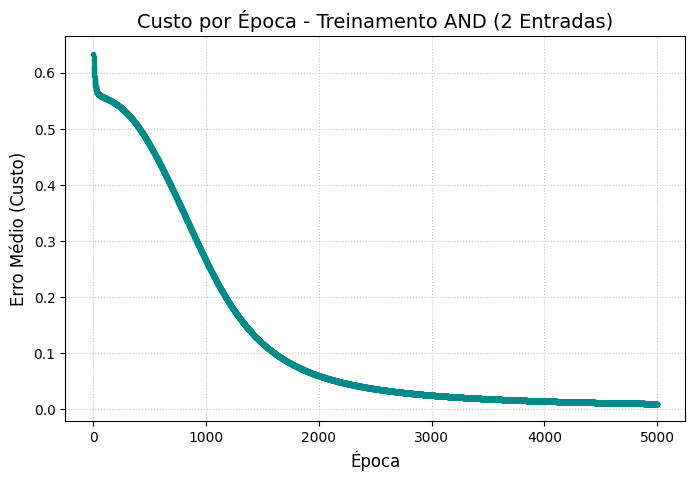

In [6]:
# Teste do Treinamento (train, backward, _calcular_custo)
print("\n--- Testando Treinamento Completo (Exemplo: Função AND) ---")

# Dados para a função AND (2 entradas)
X_and, y_and = gerar_dados(n_entradas=2, tipo_funcao='AND')

print("Dados de Treinamento (AND):")
print("X_and:\n", X_and)
print("y_and:\n", y_and)

# Criar uma nova instância da rede para o teste de treino
# Usaremos n_oculta = 4 para ter um pouco mais de capacidade para XOR depois
mlp_and = RedeNeuralMLP(n_entradas=2, n_oculta=4, n_saida=1,
                        func_ativacao_oculta='sigmoide', 
                        func_ativacao_saida='sigmoide',
                        usar_bias=True)

# Parâmetros de treinamento
taxa_aprend_and = 0.1 # Taxa de aprendizado pode precisar de ajuste
epocas_and = 5000     # Número de épocas

print(f"\nIniciando treinamento para AND com taxa={taxa_aprend_and}, épocas={epocas_and}...")
mlp_and.train(X_and, y_and, taxa_aprendizado=taxa_aprend_and, n_epocas_treino=epocas_and)

print("\n--- Treinamento para AND Concluído ---")

# Plotar curva de erro/custo
plotar_curva_erro(mlp_and.historico_custo, "Custo por Época - Treinamento AND (2 Entradas)")

# Verificar predições finais
print("\nPesos Finais após treinamento para AND:")
print("W1 (Entrada -> Oculta):\n", mlp_and.W1)
print("W2 (Oculta -> Saída):\n", mlp_and.W2)

print("\nPredições finais no conjunto de treino AND:")
predicoes_classes_and = mlp_and.predict_classes(X_and)
probabilidades_and = mlp_and.predict_proba(X_and)

for i in range(len(X_and)):
    print(f"Entrada: {X_and[i]}, Saída Real: {y_and[i][0]}, Probabilidade Predita: {probabilidades_and[i][0]:.4f}, Classe Predita: {predicoes_classes_and[i][0]}")

# Calcular acurácia
acuracia_and = np.mean(predicoes_classes_and == y_and) * 100
print(f"\nAcurácia final no treino AND: {acuracia_and:.2f}%")
assert acuracia_and > 90, "Acurácia para AND deveria ser alta!" # Esperamos 100%

print("\n--- Teste de Treinamento AND Concluído ---")